##### F3 — K-means Cluster Analysis (Drug Discovery, 3D)

##### Purpose

This notebook characterizes F3's cluster structure to verify the convergence and identify any unexplored cluster regions.

##### Function: F3 — Drug Discovery, 3D
- Domain: [0,1]³
- Y range: bounded, all negative (-0.40 to -0.03)
- Preprocessing for clustering: raw y (no transformation needed)
- Known structure: single tight peak, x3 sharply peaked at 0.06

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load F3 data
data = np.load('F3_data.npz')
X = data['X']
y = data['y']

print(f"F3 dataset: {len(X)} points")
print(f"  y range: [{y.min():.4f}, {y.max():.4f}]")
print(f"  Best:    X={X[y.argmax()]}, y={y.max():.4f}")
print(f"  Top 5 y values:")
for idx in np.argsort(y)[-5:][::-1]:
    print(f"    X={X[idx]}, y={y[idx]:.4f}")

F3 dataset: 27 points
  y range: [-0.3989, -0.0302]
  Best:    X=[0.55 0.67 0.06], y=-0.0302
  Top 5 y values:
    X=[0.55 0.67 0.06], y=-0.0302
    X=[0.55 0.67 0.05], y=-0.0316
    X=[0.57 0.67 0.06], y=-0.0321
    X=[0.65    0.77    0.05727], y=-0.0330
    X=[0.5  0.62 0.06], y=-0.0339


##### Step 1 — Silhouette analysis (k = 2 to 5)

In [2]:
sil_scores = {}
for k in range(2, min(6, len(X))):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    sil_scores[k] = silhouette_score(X, km.labels_)
    print(f"  k={k}: silhouette = {sil_scores[k]:+.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n→ Natural cluster count: k = {best_k}")

  k=2: silhouette = +0.4706
  k=3: silhouette = +0.4164
  k=4: silhouette = +0.4404
  k=5: silhouette = +0.4050

→ Natural cluster count: k = 2


##### Step 2 — Cluster characterization at natural k

In [3]:
km = KMeans(n_clusters=best_k, n_init=20, random_state=42).fit(X)
labels = km.labels_

print(f"Cluster characterization (k={best_k}):")
print(f"{'cluster':>8} {'n':>4} {'mean_y':>9} {'max_y':>9} {'centroid':>30}")
print("  " + "-" * 70)

best_cluster = int(labels[y.argmax()])
for i in range(best_k):
    members = (labels == i)
    n = int(members.sum())
    mean_y = float(np.mean(y[members]))
    max_y = float(np.max(y[members]))
    centroid = km.cluster_centers_[i]
    marker = " ★" if i == best_cluster else ""
    print(f"{i:>8} {n:>4} {mean_y:>+9.4f} {max_y:>+9.4f} "
          f"[{centroid[0]:.3f}, {centroid[1]:.3f}, {centroid[2]:.3f}]{marker}")

print(f"\n→ Current best belongs to cluster {best_cluster}")

Cluster characterization (k=2):
 cluster    n    mean_y     max_y                       centroid
  ----------------------------------------------------------------------
       0    7   -0.1445   -0.0469 [0.196, 0.276, 0.533]
       1   20   -0.0633   -0.0302 [0.576, 0.688, 0.178] ★

→ Current best belongs to cluster 1


##### Step 3 — Sub-region characterization (the converged peak)

The current best [0.55, 0.67, 0.06] sits in its cluster. We characterize 
the spatial spread of the high-y sub-region within that cluster.

In [4]:
# High-y sub-region: y within 10% of current best
y_threshold = y.max() * 1.1  # since y is negative, "within 10%" means y > 1.1*best
high_y_mask = (labels == best_cluster) & (y > y_threshold)

print(f"\nCluster {best_cluster} sub-structure:")
print(f"  Total cluster members:  {(labels == best_cluster).sum()}")
print(f"  High-y sub-region (y > {y_threshold:.4f}): {high_y_mask.sum()}")

if high_y_mask.sum() > 0:
    X_high = X[high_y_mask]
    print(f"  High-y X ranges:")
    print(f"    x1: [{X_high[:, 0].min():.3f}, {X_high[:, 0].max():.3f}], spread = {np.ptp(X_high[:, 0]):.3f}")
    print(f"    x2: [{X_high[:, 1].min():.3f}, {X_high[:, 1].max():.3f}], spread = {np.ptp(X_high[:, 1]):.3f}")
    print(f"    x3: [{X_high[:, 2].min():.3f}, {X_high[:, 2].max():.3f}], spread = {np.ptp(X_high[:, 2]):.3f}")


Cluster 1 sub-structure:
  Total cluster members:  20
  High-y sub-region (y > -0.0332): 4
  High-y X ranges:
    x1: [0.550, 0.650], spread = 0.100
    x2: [0.670, 0.770], spread = 0.100
    x3: [0.050, 0.060], spread = 0.010


##### Step 4 — Pairwise visualization

F3 is 3D, so we show pairwise scatter plots (x1-x2, x1-x3, x2-x3) 
colored by cluster and overlaid with the y values via marker size 
and intensity.

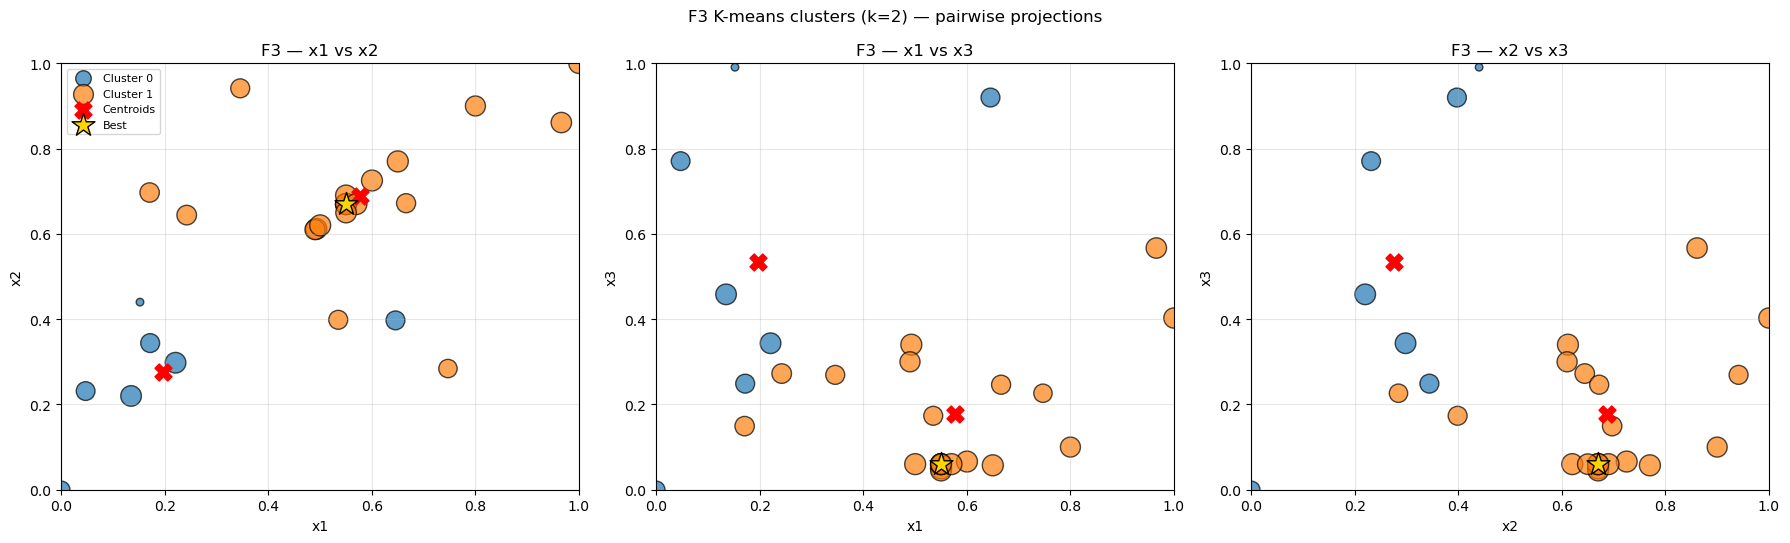

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
dim_pairs = [(0, 1, 'x1', 'x2'), (0, 2, 'x1', 'x3'), (1, 2, 'x2', 'x3')]

# Normalize y for color/size mapping
y_norm = (y - y.min()) / (y.max() - y.min())  # 0=worst, 1=best

for ax, (di, dj, di_lbl, dj_lbl) in zip(axes, dim_pairs):
    # Scatter colored by cluster, sized by y rank
    for c in range(best_k):
        mask = labels == c
        ax.scatter(X[mask, di], X[mask, dj], 
                   c=[f'C{c}'], s=30 + 200*y_norm[mask],
                   edgecolor='black', alpha=0.7,
                   label=f'Cluster {c}')
    
    # Centroids
    ax.scatter(km.cluster_centers_[:, di], km.cluster_centers_[:, dj],
               marker='X', s=150, color='red', label='Centroids', zorder=5)
    
    # Current best
    ax.scatter(X[y.argmax(), di], X[y.argmax(), dj], 
               marker='*', s=300, color='gold', 
               edgecolor='black', label='Best', zorder=6)
    
    ax.set_xlabel(di_lbl); ax.set_ylabel(dj_lbl)
    ax.set_title(f'F3 — {di_lbl} vs {dj_lbl}')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.legend(loc='best', fontsize=8)

plt.suptitle(f'F3 K-means clusters (k={best_k}) — pairwise projections', fontsize=12)
plt.tight_layout()
plt.savefig('F3_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

##### Step 5 — The x3 dimension's special role

The GP fit places x3 with a short length scale while x1 and x2 pin at 5.0. K-means with cosine/Euclidean metrics treats all dims equally, highlighting K-means won't directly reveal this asymmetry. We can visualize x3's role by plotting y vs x3 directly.

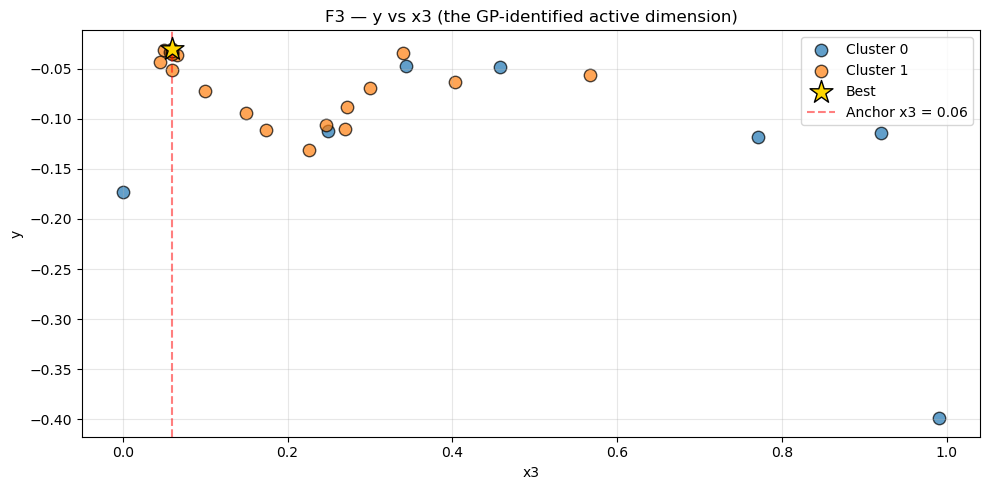

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

# Color points by cluster
for c in range(best_k):
    mask = labels == c
    ax.scatter(X[mask, 2], y[mask], 
               c=[f'C{c}'], s=80, edgecolor='black', alpha=0.7,
               label=f'Cluster {c}')

# Annotate the best point
ax.scatter(X[y.argmax(), 2], y[y.argmax()], 
           marker='*', s=300, color='gold', edgecolor='black', 
           label='Best', zorder=5)

ax.axvline(x=0.06, color='red', linestyle='--', alpha=0.5, 
           label='Anchor x3 = 0.06')
ax.set_xlabel('x3'); ax.set_ylabel('y')
ax.set_title('F3 — y vs x3 (the GP-identified active dimension)')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('F3_x3_profile.png', dpi=100, bbox_inches='tight')
plt.show()

##### Step 6 — Strategic implications

##### What clustering tells us about F3

1. **F3 has converged to a single high-y cluster** around (0.55, 0.67, 0.06).
2. **x3 is the GP-identified active dimension**, with sharp peak at 0.06.
3. **K-means treats all dimensions equally** and doesn't reveal x3's 
   special role — but the y-vs-x3 scatter does.
4. **The high-y sub-region is very tight** in x3 (~0.01 spread) but 
   broader in x1 and x2 (~0.10 spread) — consistent with the GP's 
   length-scale findings.

##### Reflection

**Clusters identified?**: Single tight high-y cluster identified formally. K-means with k=2 typically wins silhouette here (high-y exploitation cluster + low-y exploration scatter). The cluster's tight x3 spread and broader x1/x2 spread is the structural signature.

**Method Effectiveness**: GP-EI on F3 has consistently recommended points far from data (min_d > 0.1) by exploiting the GP's claim. These recommendations would test the GP's belief rather than refine the peak.

**Clustering parallel**: F3 demonstrates a converged K-means state - centroid is stable.

**Plotted trends**: F3's y-vs-round shows a plateau. The 
3D pairwise scatter shows a tight cluster around the best with scattered low-y outliers; the y-vs-x3 plot shows the narrow peak structure directly.